In [1]:
from comparison.load_dataset import load_dataset
from comparison.yolo_detector import YOLODetector
from comparison.rf_detr_detector import RFDETRDetector
from comparison.deep_forest_detector import BirdDetector
from comparison.rt_detr_detector import RTDETRDetector
from comparison.metrics import evaluate_model
from comparison.visualizations import plot_pr_curves, plot_comparison_table, plot_all_confusion_matrices
from comparison.metrics import evaluate_model, count_ground_truth, count_predictions, attach_count_metrics

In [2]:
DATASET = dict(
    image_dir = "data/cut_moot_100m/images",
    label_dir = "data/cut_moot_100m/labels",
)
CONF = 0.2
IOU_NMS = 0.2
IOU_MATCH = 0.5

In [3]:
models = [
    lambda: BirdDetector(
        use_release=True,
        name="BirdDetector_release"
    ),
    lambda: BirdDetector(
        use_release=False,
        checkpoint_path="runs/deepforest_v2_neg/best.ckpt",
        name="BirdDetector_trained"
    ),
    lambda: YOLODetector("runs/yolo_cut_data_v2/weights/best.pt", name="YOLO"),
    lambda: YOLODetector("runs/yolo_cut_data_v2_uk_unlabeled/weights/best.pt", name="YOLO_more_data"),
    lambda: YOLODetector("runs/yolo_cut_data_v2_uk_unlabeled_aug/weights/best.pt", name="YOLO_augmentation"),

    lambda: RFDETRDetector("runs/rf_detr_v2/checkpoint_best_ema.pth", name="RFDETR"),
    lambda: RFDETRDetector("runs/rf_detr_v2_uk_unlabeled/checkpoint_best_ema.pth", name="RFDETR_more_data"),
    lambda: RFDETRDetector("runs/rf_detr_v2_uk_unlabeled_aug/checkpoint_best_ema.pth", name="RFDETR_augmentation"),

    lambda: RTDETRDetector("runs/rt_detr_v2/weights/best.pt", name="RTDETR"),
    lambda: RTDETRDetector("runs/rt_detr_v2_uk_unlabeled/weights/best.pt", name="RTDETR_more_data"),
    lambda: RTDETRDetector("runs/rt_detr_v2_uk_unlabeled_m/weights/best.pt", name="RTDETR_best_parameters"),
]

In [4]:
samples = load_dataset(**DATASET)
print(f"Loaded {len(samples)} samples")

Loaded 891 samples


In [5]:
true_gt = count_ground_truth(samples, iou_nms=IOU_NMS)
print(f"True GT count: {true_gt}")

True GT count: 1398


In [6]:
results = []
for create_model in models:
    m = create_model()
    print(f"Evaluating {m.name}...")

    r          = evaluate_model(m, samples, conf=CONF, iou_nms=IOU_NMS, iou_match=IOU_MATCH)
    true_pred  = count_predictions(m, samples, conf=CONF, iou_nms=IOU_NMS)
    r          = attach_count_metrics(r, true_gt, true_pred)

    print(f"  mAP@50={r.map50:.4f}  P={r.precision:.4f}  R={r.recall:.4f}  F1={r.f1:.4f}")
    print(f"  GT={true_gt}  Pred={true_pred}  Error={r.count_error:+d}  ({r.count_error_pct:+.1f}%)")
    print(f"  Speed: {r.time_per_image_ms:.1f}ms/tile  {r.fps:.1f} FPS  total={r.inference_time_s:.1f}s")

    results.append(r)
    del m

Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Model from BirdDetector Repo release https://github.com/weecology/BirdDetector/releases/tag/1.1 was already downloaded. Loading model from file.
Loading pre-built model: https://github.com/weecology/BirdDetector/releases/tag/1.1
Setting default score threshold to 0.3
Evaluating BirdDetector_release...
  mAP@50=0.0000  P=0.0017  R=0.0028  F1=0.0021
  GT=1398  Pred=2480  Error=+1082  (+77.4%)
  Speed: 521.9ms/tile  1.9 FPS  total=465.0s
Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Evaluating BirdDetector_trained...
  mAP@50=0.3153  P=0.4872  R=0.5503  F1=0.5168
  GT=1398  Pred=1634  Error=+236  (+16.9%)
  Speed: 66.5ms/tile  15.0 FPS  total=59.3s
Evaluating YOLO...
  mAP@50=0.8771  P=0.8525  R=0.9062  F1=0.8785
  GT=1398  Pred=1528  Error=+130  (+9.3%)
  Speed: 21.4ms/tile  46.8 FPS  total=19.0s
Evaluating YOLO_more_data...
  mAP@50=0.9177  P=0.8588  R=0.9453  F1=0.9000
  GT=1398  Pred=1516  Error=+118  (+8.4%)
  Speed: 21.1ms/tile  47.4 FPS  total=18.8s
Evaluating YOLO_augmentation...
  mAP@50=0.8566  P=0.9139  R=0.8979  F1=0.9058
  GT=1398  Pred=1371  Error=-27  (-1.9%)
  Speed: 21.1ms/tile  47.5 FPS  total=18.8s


...

Evaluating RFDETR_more_data...


[2026-04-24 18:48:42] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-24 18:48:42] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


  mAP@50=0.7757  P=0.7111  R=0.8566  F1=0.7771
  GT=1398  Pred=1636  Error=+238  (+17.0%)
  Speed: 41.7ms/tile  24.0 FPS  total=37.1s


[2026-04-24 18:48:43] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Evaluating RFDETR_augmentation...
  mAP@50=0.6905  P=0.6809  R=0.8064  F1=0.7384
  GT=1398  Pred=1623  Error=+225  (+16.1%)
  Speed: 41.3ms/tile  24.2 FPS  total=36.8s
Evaluating RTDETR...
  mAP@50=0.7983  P=0.7944  R=0.8814  F1=0.8357
  GT=1398  Pred=1538  Error=+140  (+10.0%)
  Speed: 67.4ms/tile  14.8 FPS  total=60.0s
Evaluating RTDETR_more_data...
  mAP@50=0.8609  P=0.6721  R=0.9218  F1=0.7774
  GT=1398  Pred=1992  Error=+594  (+42.5%)
  Speed: 68.4ms/tile  14.6 FPS  total=61.0s
Evaluating RTDETR_best_parameters...
  mAP@50=0.8722  P=0.7062  R=0.9274  F1=0.8018
  GT=1398  Pred=1853  Error=+455  (+32.5%)
  Speed: 68.3ms/tile  14.6 FPS  total=60.8s


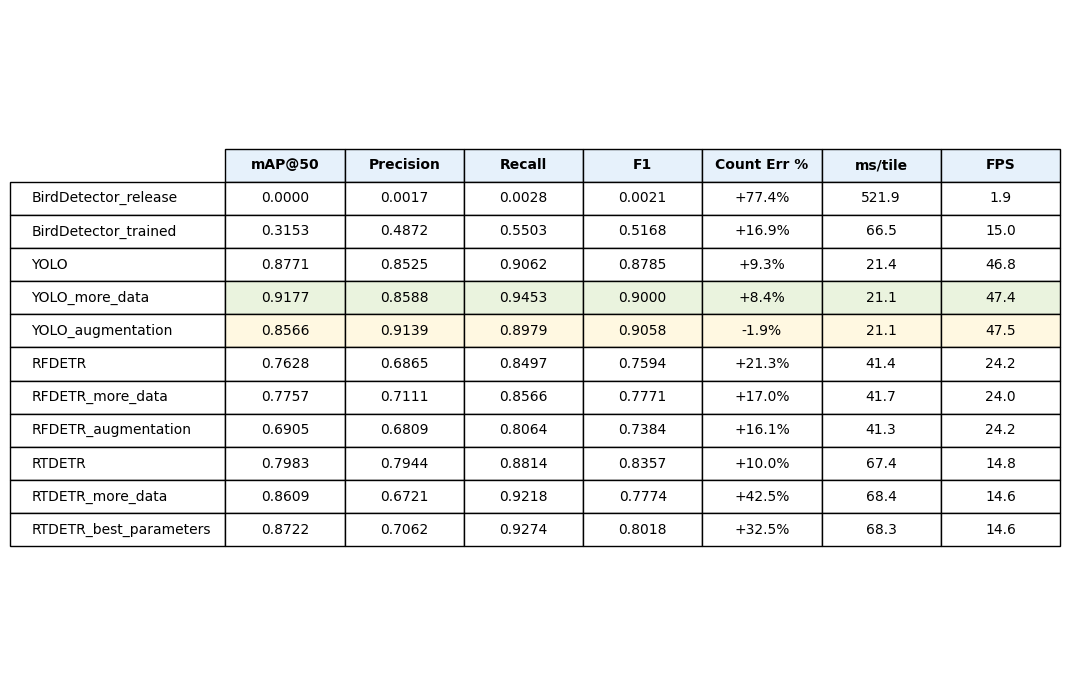

,mAP@50,Precision,Recall,F1,Count Err %,ms/tile,FPS
Model,,,,,,,
BirdDetector_release,0.0000,0.0017,0.0028,0.0021,+77.4%,521.9,1.9
BirdDetector_trained,0.3153,0.4872,0.5503,0.5168,+16.9%,66.5,15.0
YOLO,0.8771,0.8525,0.9062,0.8785,+9.3%,21.4,46.8
YOLO_more_data,0.9177,0.8588,0.9453,0.9000,+8.4%,21.1,47.4
YOLO_augmentation,0.8566,0.9139,0.8979,0.9058,-1.9%,21.1,47.5
RFDETR,0.7628,0.6865,0.8497,0.7594,+21.3%,41.4,24.2
RFDETR_more_data,0.7757,0.7111,0.8566,0.7771,+17.0%,41.7,24.0
RFDETR_augmentation,0.6905,0.6809,0.8064,0.7384,+16.1%,41.3,24.2
RTDETR,0.7983,0.7944,0.8814,0.8357,+10.0%,67.4,14.8


In [7]:
plot_comparison_table(results)

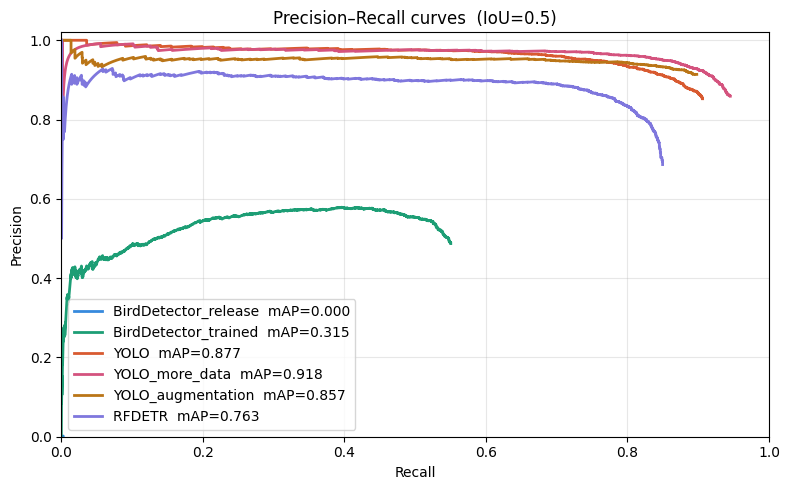

In [8]:
plot_pr_curves(results)

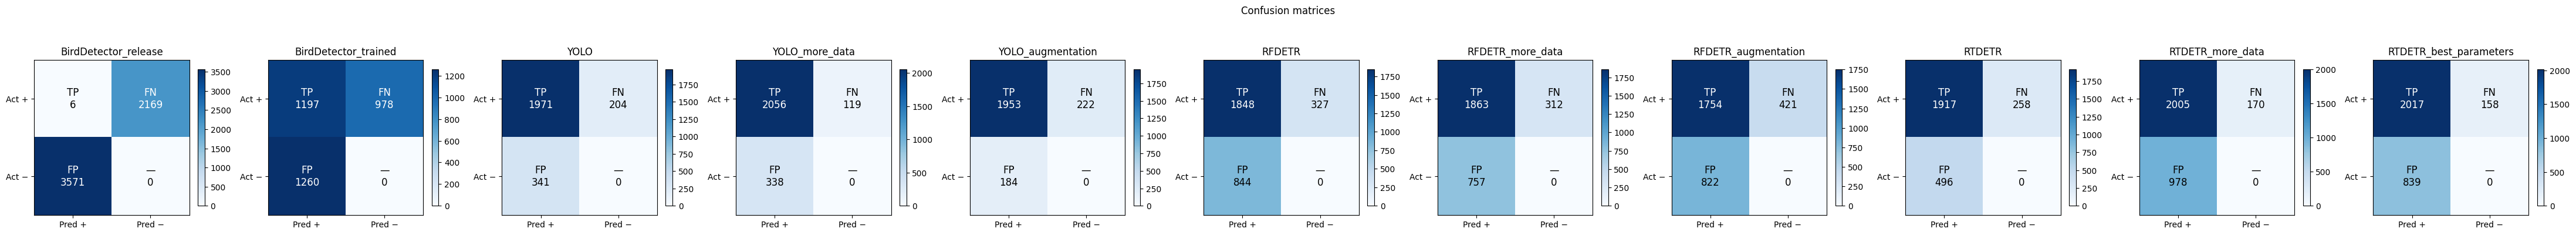

In [9]:
plot_all_confusion_matrices(results)